# 📊 Regresi Linear dengan Dataset Fuel Consumption

Modul ini bertujuan untuk membuat model **Regresi Linear Sederhana** menggunakan dataset konsumsi bahan bakar mobil.

Dataset:
FuelConsumptionCo2.csv

## 📦 Import Library

Library yang digunakan:
- pandas → untuk membaca dan mengolah data
- numpy → perhitungan numerik
- matplotlib → visualisasi data
- scikit-learn → model machine learning

In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

## 📂 Load Dataset

Dataset dibaca dari file CSV menggunakan pandas.

In [3]:
df = pd.read_csv("FuelConsumptionCo2.csv")

# tampilkan 5 data pertama
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


## 🔍 Seleksi Kolom

Mengambil kolom yang relevan:
- ENGINESIZE
- CYLINDERS
- FUELCONSUMPTION_CITY
- CO2EMISSIONS

In [4]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_CITY','CO2EMISSIONS']]
cdf.head(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,CO2EMISSIONS
0,2.0,4,9.9,196
1,2.4,4,11.2,221
2,1.5,4,6.0,136
3,3.5,6,12.7,255
4,3.5,6,12.1,244
5,3.5,6,11.9,230
6,3.5,6,11.8,232
7,3.7,6,12.8,255
8,3.7,6,13.4,267


## 📊 Visualisasi 1

Melihat hubungan antara:
- Fuel Consumption (city)
- CO2 Emissions

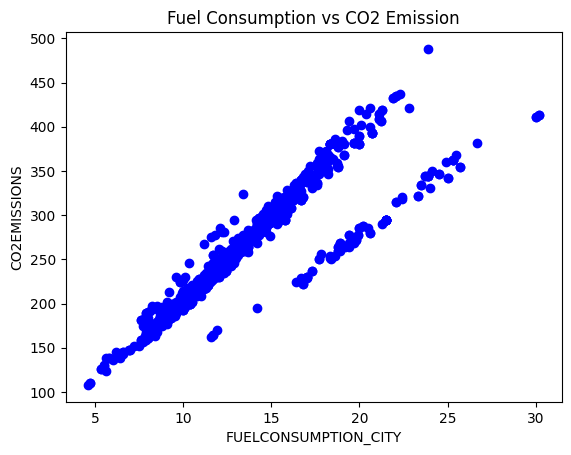

In [5]:
plt.scatter(cdf.FUELCONSUMPTION_CITY, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("FUELCONSUMPTION_CITY")
plt.ylabel("CO2EMISSIONS")
plt.title("Fuel Consumption vs CO2 Emission")
plt.show()

## 📊 Visualisasi 2

Melihat hubungan antara:
- Engine Size
- CO2 Emissions

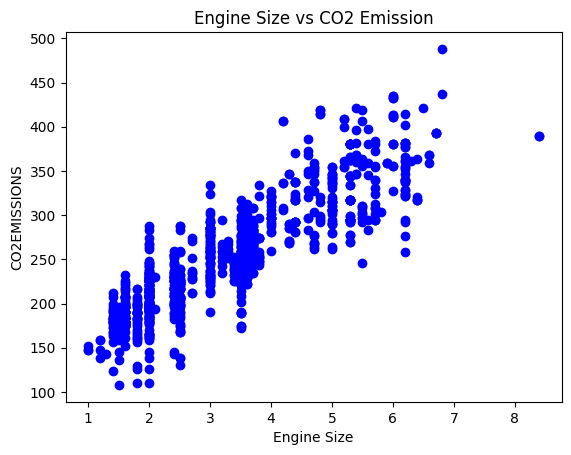

In [6]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("Engine Size")
plt.ylabel("CO2EMISSIONS")
plt.title("Engine Size vs CO2 Emission")
plt.show()

## 🔀 Split Data

Membagi data menjadi:
- Training (80%)
- Testing (20%)

In [7]:
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]

## 📊 Visualisasi Data Training

Menampilkan data training untuk melihat pola hubungan.

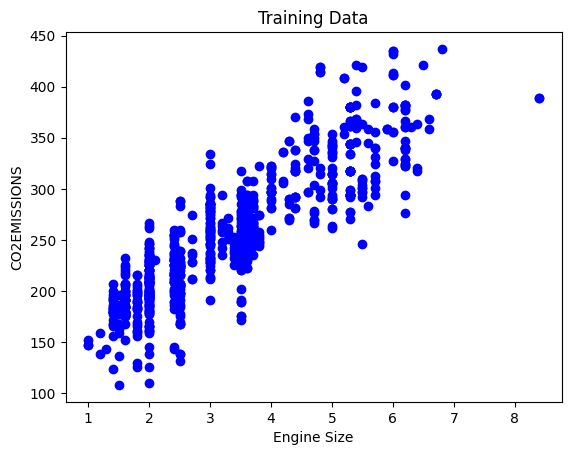

In [8]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='blue')
plt.xlabel("Engine Size")
plt.ylabel("CO2EMISSIONS")
plt.title("Training Data")
plt.show()

## 🤖 Membuat Model Regresi Linear

Langkah:
1. Mengambil variabel X (Engine Size)
2. Mengambil variabel Y (CO2 Emissions)
3. Melatih model menggunakan Linear Regression

In [9]:
regr = LinearRegression()

train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])

regr.fit(train_x, train_y)

print("Coefficients:", regr.coef_)
print("Intercept:", regr.intercept_)

Coefficients: [[39.26595261]]
Intercept: [124.24896502]


## 📈 Visualisasi Hasil Regresi

- Titik biru → data asli
- Garis merah → hasil prediksi model

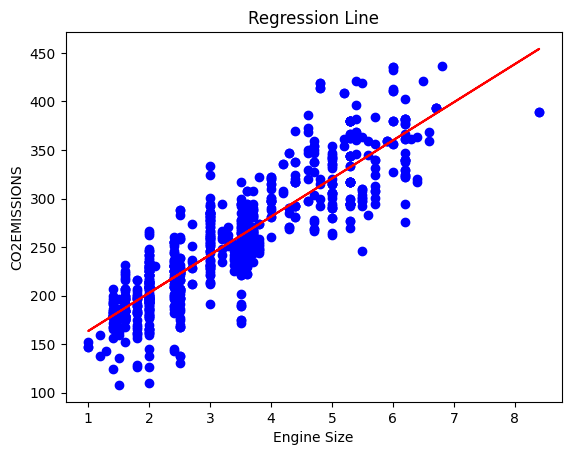

In [10]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='blue')
plt.plot(train_x, regr.coef_[0][0]*train_x + regr.intercept_[0], '-r')

plt.xlabel("Engine Size")
plt.ylabel("CO2EMISSIONS")
plt.title("Regression Line")
plt.show()

## 🧠 Evaluasi Model

Mengukur performa model menggunakan R² Score.

In [11]:
from sklearn.metrics import r2_score

test_x = np.asanyarray(test[['ENGINESIZE']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])

test_y_pred = regr.predict(test_x)

print("R2-score:", r2_score(test_y, test_y_pred))

R2-score: 0.725997595312151
